In [1]:
# Cell 1: imports & configuration

import os
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path

# Base directory where your simulation CSVs + EPH CSVs live
RESULTS_DIR = Path("../result_email_26feb/unweighted")

# Helper: identify node columns (same logic as in EPH-v3.py)
def get_node_columns(df):
    cols = []
    for c in df.columns:
        s = str(c)
        if s.isdigit() or s.lstrip("-").isdigit():
            cols.append(c)
    return cols


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/260353562.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy import stats


In [2]:
# Cell 2: helper to compute confidence intervals for the mean

def mean_confidence_interval(values, alpha=0.05):
    """
    Compute (mean, lower, upper) for the given 1D array-like values
    using a t-based confidence interval.

    NaNs are dropped.
    """
    vals = np.array(values, dtype=float)
    vals = vals[~np.isnan(vals)]
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan

    mean = np.mean(vals)
    sem = stats.sem(vals)  # standard error of the mean
    # t critical value
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    half_width = t_crit * sem
    return mean, mean - half_width, mean + half_width


In [3]:
# Cell 3: CI of EPH for a given k from EPH-v3_step-k CSV

def load_eph_step_k(network_name, theta, prob_complex, k):
    """
    Load the EPH-v3_step-k CSV for a given (network, theta, prob_complex, k).

    Returns
    -------
    df : pd.DataFrame
        The loaded dataframe.
    """
    # Base complex file name (without the EPH suffix)
    base_name = f"unweighted_complex_{network_name}_theta_{theta}_prob_{prob_complex}.csv"
    eph_name = base_name.replace(".csv", f"_EPH-v3_step-{k}.csv")
    csv_path = RESULTS_DIR / eph_name

    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    return pd.read_csv(csv_path)


def eph_ci_for_step_k(network_name, theta, prob_complex, k, alpha=0.05):
    """
    Compute mean and CI of EPH for EPH-v3_step-k for a given parameter combo.
    """
    df = load_eph_step_k(network_name, theta, prob_complex, k)
    if "EPH" not in df.columns:
        raise ValueError("EPH column not found in the EPH-v3_step-k CSV.")

    mean, lower, upper = mean_confidence_interval(df["EPH"], alpha=alpha)
    return {
        "network": network_name,
        "theta": theta,
        "prob_complex": prob_complex,
        "k": k,
        "mean_EPH": mean,
        "CI_lower": lower,
        "CI_upper": upper,
    }


In [4]:
# Example: one configuration
network_name = "email_eu_modified"
theta = 3
prob_complex = 0.2
k = 4

eph_ci = eph_ci_for_step_k(network_name, theta, prob_complex, k)
eph_ci


{'network': 'email_eu_modified',
 'theta': 3,
 'prob_complex': 0.2,
 'k': 4,
 'mean_EPH': np.float64(1.0692183536351667),
 'CI_lower': np.float64(1.0679290808992943),
 'CI_upper': np.float64(1.0705076263710391)}

In [5]:
# Cell 4: CI of ratio of simple adoption up to step k

def load_complex_and_infection_type(network_name, theta, prob_complex):
    """
    Load the base complex contagion CSV and the corresponding infection_type CSV.
    """
    base_name = f"unweighted_complex_{network_name}_theta_{theta}_prob_{prob_complex}.csv"
    base_path = RESULTS_DIR / base_name
    inf_type_path = RESULTS_DIR / base_name.replace(".csv", "_infection_type.csv")

    if not base_path.exists():
        raise FileNotFoundError(f"Base contagion CSV not found: {base_path}")
    if not inf_type_path.exists():
        raise FileNotFoundError(f"Infection type CSV not found: {inf_type_path}")

    df_order = pd.read_csv(base_path)
    df_type = pd.read_csv(inf_type_path)

    return df_order, df_type


def simple_ratio_up_to_k(df_order, df_type, k):
    """
    Compute per-simulation ratio of simple vs complex adoptions up to step k.

    Returns
    -------
    ratios : np.ndarray
        One ratio per simulation (NaN where undefined).
    """
    node_cols_order = get_node_columns(df_order)
    node_cols_type = get_node_columns(df_type)

    # Ensure same node columns, same order
    if node_cols_order != node_cols_type:
        raise ValueError("Node columns in order and infection_type CSVs do not match.")

    order_vals = df_order[node_cols_order].to_numpy(dtype=float)
    type_vals = df_type[node_cols_type].to_numpy(dtype=float)

    n_sims, n_nodes = order_vals.shape
    ratios = np.full(n_sims, np.nan, dtype=float)

    for i in range(n_sims):
        steps = order_vals[i, :]   # infection time (could be NaN for never infected)
        types = type_vals[i, :]    # 0 (seed/none), 1 (complex), 2 (simple)

        # Nodes that (a) got infected and (b) did so by step <= k
        mask = (~np.isnan(steps)) & (steps <= k)

        simple_count = np.sum((types == 2) & mask)
        complex_count = np.sum((types == 1) & mask)

        if complex_count > 0:
            ratios[i] = simple_count / complex_count
        else:
            ratios[i] = np.nan  # undefined ratio if no complex adoptions up to step k

    return ratios


def simple_ratio_ci_up_to_k(network_name, theta, prob_complex, k, alpha=0.05):
    """
    Convenience wrapper:
    load CSVs, compute per-simulation ratio(simple/complex) up to step k,
    then return mean and CI.
    """
    df_order, df_type = load_complex_and_infection_type(network_name, theta, prob_complex)
    ratios = simple_ratio_up_to_k(df_order, df_type, k)

    mean, lower, upper = mean_confidence_interval(ratios, alpha=alpha)
    return {
        "network": network_name,
        "theta": theta,
        "prob_complex": prob_complex,
        "k": k,
        "mean_simple_ratio": mean,
        "CI_lower": lower,
        "CI_upper": upper,
    }


In [6]:
# Example: ratio CI for the same configuration and k
network_name = "email_eu_modified"
theta = 3
prob_complex = 0.2
k = 4

ratio_ci = simple_ratio_ci_up_to_k(network_name, theta, prob_complex, k)
ratio_ci


{'network': 'email_eu_modified',
 'theta': 3,
 'prob_complex': 0.2,
 'k': 4,
 'mean_simple_ratio': np.float64(0.16853295309552588),
 'CI_lower': np.float64(0.16482022338848362),
 'CI_upper': np.float64(0.17224568280256813)}

In [13]:
# Cell 5: summarize over multiple k values for a given theta/prob

network_name = "email_eu_modified"
theta = 3
prob_complex = 0.2
k_values = [1, 2, 3, 4]

rows = []
for k in k_values:
    eph_ci = eph_ci_for_step_k(network_name, theta, prob_complex, k)
    ratio_ci = simple_ratio_ci_up_to_k(network_name, theta, prob_complex, k)

    rows.append({
        "k": k,
        "mean_EPH": eph_ci["mean_EPH"],
        "EPH_CI_lower": eph_ci["CI_lower"],
        "EPH_CI_upper": eph_ci["CI_upper"],
        "mean_simple_ratio": ratio_ci["mean_simple_ratio"],
        "ratio_CI_lower": ratio_ci["CI_lower"],
        "ratio_CI_upper": ratio_ci["CI_upper"],
    })

summary_df = pd.DataFrame(rows)
summary_df.corr()


,k,mean_EPH,EPH_CI_lower,EPH_CI_upper,mean_simple_ratio,ratio_CI_lower,ratio_CI_upper
k,1.000000,0.843184,0.864321,0.821290,-0.779524,-0.779988,-0.779210
mean_EPH,0.843184,1.000000,0.998740,0.998878,-0.992109,-0.992217,-0.992035
EPH_CI_lower,0.864321,0.998740,1.000000,0.995244,-0.984573,-0.984724,-0.984470
EPH_CI_upper,0.821290,0.998878,0.995244,1.000000,-0.996927,-0.996995,-0.996882
mean_simple_ratio,-0.779524,-0.992109,-0.984573,-0.996927,1.000000,1.000000,1.000000
ratio_CI_lower,-0.779988,-0.992217,-0.984724,-0.996995,1.000000,1.000000,0.999999
ratio_CI_upper,-0.779210,-0.992035,-0.984470,-0.996882,1.000000,0.999999,1.000000


In [15]:
# Cell A: build summary over k for a given (network, theta, prob_complex)

def build_summary_over_k(network_name, theta, prob_complex, k_values, alpha=0.05):
    rows = []
    for k in k_values:
        eph_ci = eph_ci_for_step_k(network_name, theta, prob_complex, k, alpha=alpha)
        ratio_ci = simple_ratio_ci_up_to_k(network_name, theta, prob_complex, k, alpha=alpha)

        rows.append({
            "k": k,
            "mean_EPH": eph_ci["mean_EPH"],
            "EPH_CI_lower": eph_ci["CI_lower"],
            "EPH_CI_upper": eph_ci["CI_upper"],
            "mean_simple_ratio": ratio_ci["mean_simple_ratio"],
            "ratio_CI_lower": ratio_ci["CI_lower"],
            "ratio_CI_upper": ratio_ci["CI_upper"],
        })

    return pd.DataFrame(rows)

network_name = "email_eu_modified"
theta = 3
prob_complex = 0.2
k_values = [1, 2, 3, 4]

summary_df = build_summary_over_k(network_name, theta, prob_complex, k_values)
summary_df


,k,mean_EPH,EPH_CI_lower,EPH_CI_upper,mean_simple_ratio,ratio_CI_lower,ratio_CI_upper
0,1,1.000000,1.000000,1.000000,6.218374,5.048865,7.387882
1,2,1.059495,1.055061,1.063929,0.226463,0.216003,0.236923
2,3,1.068685,1.067364,1.070006,0.167375,0.163796,0.170955
3,4,1.069218,1.067929,1.070508,0.168533,0.164820,0.172246


In [213]:
# # Cell B: phase-transition style plots vs k

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# # --- Left: EPH vs k ---
# ax = axes[0]
# ax.errorbar(
#     summary_df["k"],
#     summary_df["mean_EPH"],
#     yerr=[
#         summary_df["mean_EPH"] - summary_df["EPH_CI_lower"],
#         summary_df["EPH_CI_upper"] - summary_df["mean_EPH"]
#     ],
#     fmt="o-"
# )
# ax.set_xlabel("k (max infection step included)")
# ax.set_ylabel("EPH (mean ± CI)")
# ax.set_title(f"EPH vs k\n{network_name}, theta={theta}, prob={prob_complex}")
# ax.grid(True)

# # --- Right: simple/complex ratio vs k ---
# ax = axes[1]
# ax.errorbar(
#     summary_df["k"],
#     summary_df["mean_simple_ratio"],
#     yerr=[
#         summary_df["mean_simple_ratio"] - summary_df["ratio_CI_lower"],
#         summary_df["ratio_CI_upper"] - summary_df["mean_simple_ratio"]
#     ],
#     fmt="o-"
# )
# ax.set_xlabel("k (max infection step included)")
# ax.set_ylabel("Simple/Complex ratio (mean ± CI)")
# ax.set_title(f"Simple adoption ratio vs k\n{network_name}, theta={theta}, prob={prob_complex}")
# ax.grid(True)

# plt.tight_layout()
# plt.show()


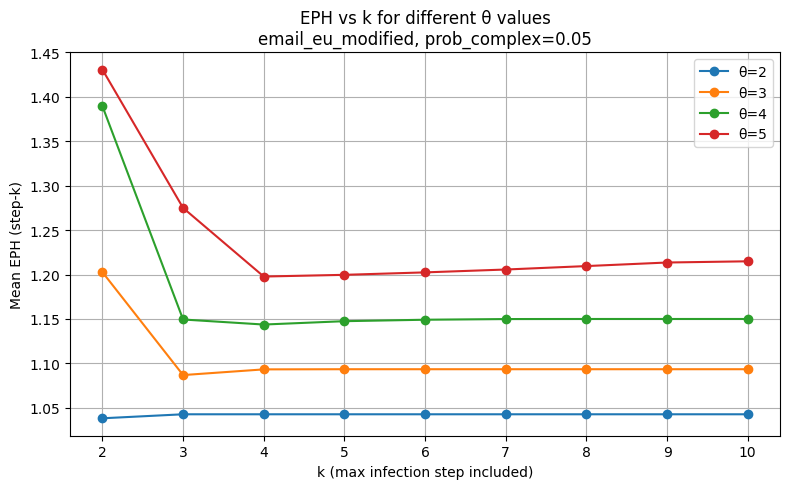

In [149]:
# Plot EPH vs k for different thetas (each theta = different color)

import matplotlib.pyplot as plt

network_name = "email_eu_modified"   # change if needed
thetas = [2, 3, 4, 5]                # the theta values you want to compare
prob_complex = 0.05               # fix one prob_complex for this plot
k_values = [ 2, 3, 4, 5, 6, 7, 8, 9, 10]  # the k values you want on the x-axis

fig, ax = plt.subplots(figsize=(8, 5))

for theta_curr in thetas:
    # summary_curr has columns: k, mean_EPH, EPH_CI_lower, EPH_CI_upper, ...
    summary_curr = build_summary_over_k(
        network_name=network_name,
        theta=theta_curr,
        prob_complex=prob_complex,
        k_values=k_values,
        alpha=0.05
    )
    
    # Plot mean EPH vs k for this theta
    ax.plot(
        summary_curr["k"],
        summary_curr["mean_EPH"],
        marker="o",
        label=f"θ={theta_curr}"
    )

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs k for different θ values\n{network_name}, prob_complex={prob_complex}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


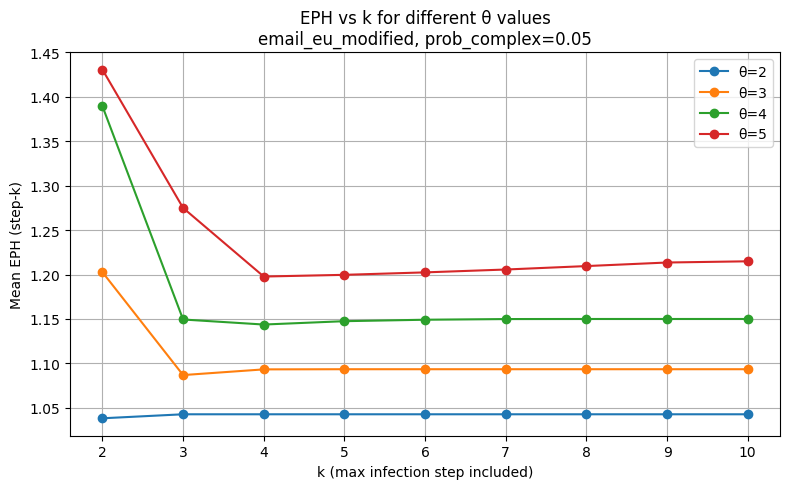

In [211]:
# Plot EPH vs k for different thetas (each theta = different color)

import matplotlib.pyplot as plt

network_name = "email_eu_modified"   # change if needed
thetas = [2, 3, 4, 5]                # the theta values you want to compare
prob_complex = 0.05          # fix one prob_complex for this plot
k_values = [ 2, 3, 4, 5, 6, 7, 8, 9, 10]  # the k values you want on the x-axis

fig, ax = plt.subplots(figsize=(8, 5))

for theta_curr in thetas:
    # summary_curr has columns: k, mean_EPH, EPH_CI_lower, EPH_CI_upper, ...
    summary_curr = build_summary_over_k(
        network_name=network_name,
        theta=theta_curr,
        prob_complex=prob_complex,
        k_values=k_values,
        alpha=0.05
    )
    
    # Plot mean EPH vs k for this theta
    ax.plot(
        summary_curr["k"],
        summary_curr["mean_EPH"],
        marker="o",
        label=f"θ={theta_curr}"
    )

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs k for different θ values\n{network_name}, prob_complex={prob_complex}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


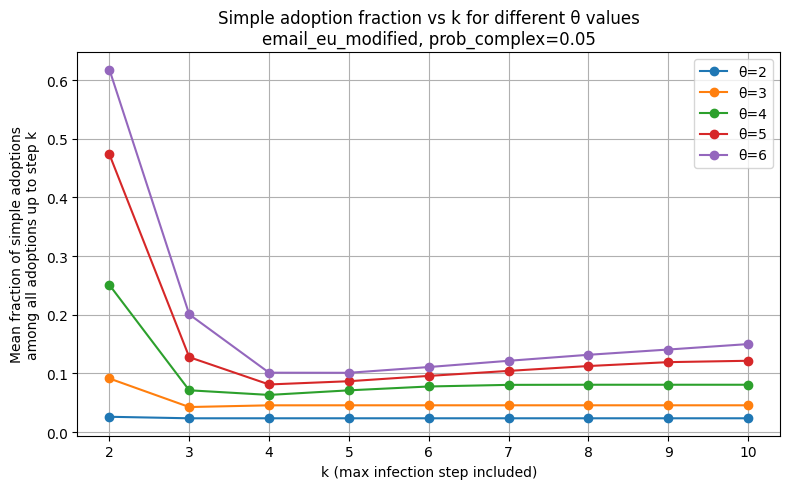

In [153]:
# Plot simple-fraction vs k for different thetas (each theta = different color)

import matplotlib.pyplot as plt

network_name = "email_eu_modified"        # change if needed
thetas = [2, 3, 4, 5, 6]                  # the theta values you want to compare
prob_complex = 0.05                       # fix one prob_complex for this plot
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]   # the k values you want on the x-axis

fig, ax = plt.subplots(figsize=(8, 5))

for theta_curr in thetas:
    summary_curr = simple_fraction_summary_over_k(
        network_name=network_name,
        theta=theta_curr,
        prob_complex=prob_complex,
        k_values=k_values
    )
    
    # Plot mean simple fraction vs k for this theta
    ax.plot(
        summary_curr["k"],
        summary_curr["mean_simple_fraction"],
        marker="o",
        label=f"θ={theta_curr}"
    )

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean fraction of simple adoptions\namong all adoptions up to step k")
ax.set_title(f"Simple adoption fraction vs k for different θ values\n{network_name}, prob_complex={prob_complex}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


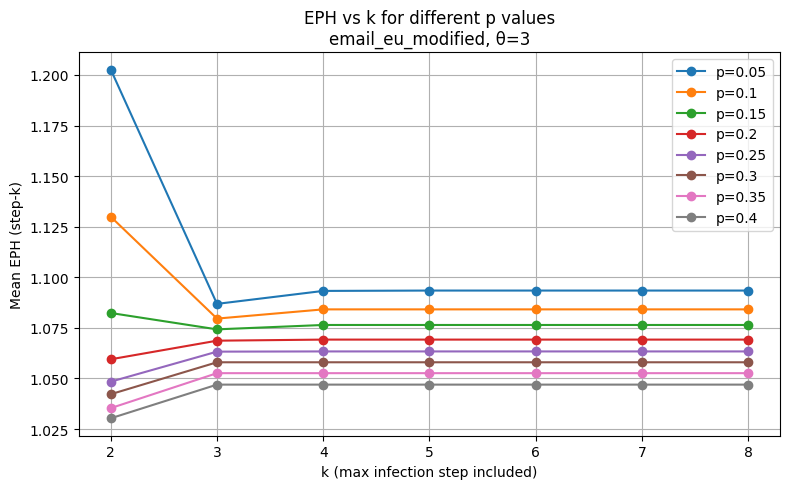

In [155]:
# Plot EPH vs k for different prob_complex values (each prob = different color)

import matplotlib.pyplot as plt

network_name = "email_eu_modified"      # change if needed
theta = 3                  # fix one theta for this plot
prob_complexes = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4]   # the prob_complex values you want to compare
k_values = [ 2, 3, 4, 5, 6, 7, 8]     # the k values you want on the x-axis

fig, ax = plt.subplots(figsize=(8, 5))

for prob_complex in prob_complexes:
    # summary_curr has columns: k, mean_EPH, EPH_CI_lower, EPH_CI_upper, ...
    summary_curr = build_summary_over_k(
        network_name=network_name,
        theta=theta,
        prob_complex=prob_complex,
        k_values=k_values,
        alpha=0.05
    )
    
    # Plot mean EPH vs k for this prob_complex
    ax.plot(
        summary_curr["k"],
        summary_curr["mean_EPH"],
        marker="o",
        label=f"p={prob_complex}"
    )

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs k for different p values\n{network_name}, θ={theta}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


In [157]:
def simple_fraction_up_to_k(df_order, df_type, k):
    """
    Compute per-simulation fraction of simple adoptions among all
    (simple + complex) adoptions up to step k.

    Returns
    -------
    fractions : np.ndarray
        One fraction per simulation (NaN where undefined).
    """
    node_cols_order = get_node_columns(df_order)
    node_cols_type = get_node_columns(df_type)

    # Ensure same node columns, same order
    if node_cols_order != node_cols_type:
        raise ValueError("Node columns in order and infection_type CSVs do not match.")

    order_vals = df_order[node_cols_order].to_numpy(dtype=float)
    type_vals = df_type[node_cols_type].to_numpy(dtype=float)

    n_sims, n_nodes = order_vals.shape
    fractions = np.full(n_sims, np.nan, dtype=float)

    for i in range(n_sims):
        steps = order_vals[i, :]   # infection time (NaN for never infected)
        types = type_vals[i, :]    # 0 (seed/none), 1 (complex), 2 (simple)

        # Nodes that (a) got infected and (b) did so by step <= k
        mask = (~np.isnan(steps)) & (steps <= k)

        simple_count = np.sum((types == 2) & mask)
        complex_count = np.sum((types == 1) & mask)
        total_adoptions = simple_count + complex_count

        if total_adoptions > 0:
            fractions[i] = simple_count / total_adoptions
        else:
            fractions[i] = np.nan  # no adoptions up to step k

    return fractions


def simple_fraction_summary_over_k(network_name, theta, prob_complex, k_values):
    """
    For a given (network, theta, prob), compute the *mean* simple fraction up to each k.

    Returns
    -------
    DataFrame with columns:
        k, mean_simple_fraction
    """
    df_order, df_type = load_complex_and_infection_type(network_name, theta, prob_complex)

    rows = []
    for k in k_values:
        fractions = simple_fraction_up_to_k(df_order, df_type, k)
        mean_fraction = np.nanmean(fractions)
        rows.append({
            "k": k,
            "mean_simple_fraction": mean_fraction,
        })

    return pd.DataFrame(rows)


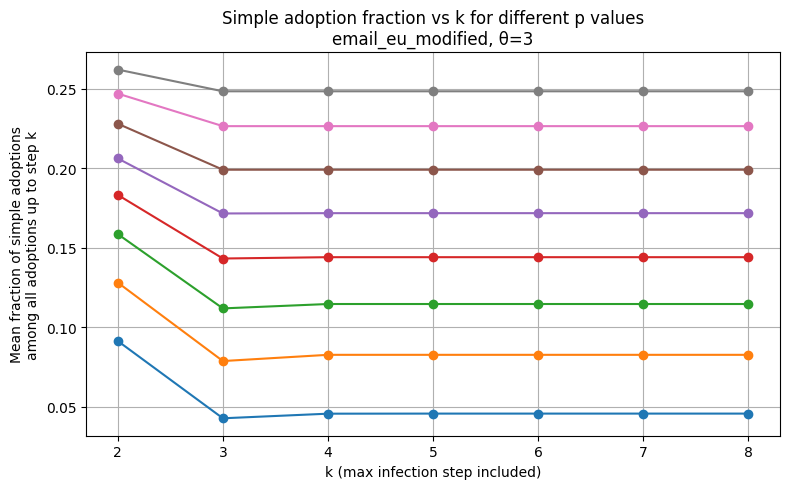

In [159]:
# Plot simple-fraction vs k for different prob_complex values (each prob = different color)

import matplotlib.pyplot as plt

network_name = "email_eu_modified"      # change if needed
# theta = 2                       # fix one theta for this plot
prob_complexes = [0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4]
k_values = [2, 3, 4, 5, 6, 7, 8]

fig, ax = plt.subplots(figsize=(8, 5))

for prob_complex in prob_complexes:
    summary_curr = simple_fraction_summary_over_k(
        network_name=network_name,
        theta=theta,
        prob_complex=prob_complex,
        k_values=k_values
    )
    
    # Plot mean simple fraction vs k for this prob_complex
    ax.plot(
        summary_curr["k"],
        summary_curr["mean_simple_fraction"],
        marker="o",
        label=f"p={prob_complex}"
    )

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean fraction of simple adoptions\namong all adoptions up to step k")
ax.set_title(f"Simple adoption fraction vs k for different p values\n{network_name}, θ={theta}")
ax.grid(True)
# ax.legend()

plt.tight_layout()
plt.show()


In [181]:
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path

# Adjust if needed
NETWORK_DIR = Path("../networks/unweighted")

def load_graph_for_network(network_name):
    """
    Load graph for a given network_name, with node labels converted to ints.
    """
    graph_path = NETWORK_DIR / f"G_unweighted_{network_name}.graphml"
    G = nx.read_graphml(graph_path)
    mapping = {node: int(float(node)) for node in G.nodes()}
    G = nx.relabel_nodes(G, mapping)
    return G


def simple_enabler_ratio_over_k(network_name, theta, prob_complex, k_values):
    """
    For a given (network, theta, prob), compute for each k in k_values the
    fraction of simple adoptions at step k that later enable at least one
    complex adoption in a neighbor.

    Returns
    -------
    result_df : pd.DataFrame with columns:
        k, mean_enabler_ratio, mean_num_simple_at_k, mean_num_enabler_simple_at_k
    """
    # Load data
    df_order, df_type = load_complex_and_infection_type(network_name, theta, prob_complex)
    G = load_graph_for_network(network_name)

    # Align node ordering between graph and CSV columns
    node_cols = get_node_columns(df_order)
    node_cols_type = get_node_columns(df_type)
    if node_cols != node_cols_type:
        raise ValueError("Node columns in order and infection_type CSVs do not match.")

    # Assumption (as in your earlier code): column order corresponds to list(G.nodes())
    node_list = np.array(list(G.nodes()))
    if len(node_list) != len(node_cols):
        raise ValueError("Number of graph nodes and node columns differ.")

    # Map node id -> index
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}

    # Precompute neighbor indices for each node index
    neighbors_idx = []
    for i, node in enumerate(node_list):
        neighs = [node_to_idx[nbr] for nbr in G.neighbors(node)]
        neighbors_idx.append(np.array(neighs, dtype=int))

    order_vals = df_order[node_cols].to_numpy(dtype=float)
    type_vals = df_type[node_cols].to_numpy(dtype=float)

    n_sims, n_nodes = order_vals.shape

    # For each k, we'll collect per-simulation ratios and counts
    rows = []

    for k in k_values:
        ratios_k = []
        simple_counts_k = []
        enabler_simple_counts_k = []

        for s in range(n_sims):
            steps = order_vals[s, :]   # infection time per node (NaN if never)
            types = type_vals[s, :]    # 0=seed/none, 1=complex, 2=simple

            # --- 1) Find all simple nodes that are "enablers" in this simulation ---
            enabler_simple = np.zeros(n_nodes, dtype=bool)

            # Loop over complex adopters
            for j in range(n_nodes):
                if np.isnan(steps[j]):
                    continue
                if types[j] != 1:  # not complex adoption
                    continue

                t_j = steps[j]
                # Look at neighbors infected before this complex adoption
                for i in neighbors_idx[j]:
                    if np.isnan(steps[i]):
                        continue
                    if types[i] == 2 and steps[i] < t_j:
                        enabler_simple[i] = True

            # --- 2) Now restrict to simple adoptions happening exactly at step k ---
            is_simple_at_k = (types == 2) & (~np.isnan(steps)) & (steps == k)

            num_simple_k = np.sum(is_simple_at_k)
            num_enabler_simple_k = np.sum(is_simple_at_k & enabler_simple)

            simple_counts_k.append(num_simple_k)
            enabler_simple_counts_k.append(num_enabler_simple_k)

            if num_simple_k > 0:
                ratios_k.append(num_enabler_simple_k / num_simple_k)
            else:
                ratios_k.append(np.nan)

        rows.append({
            "k": k,
            "mean_enabler_ratio": np.nanmean(ratios_k),
            "mean_num_simple_at_k": np.mean(simple_counts_k),
            "mean_num_enabler_simple_at_k": np.mean(enabler_simple_counts_k),
        })

    return pd.DataFrame(rows)


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),


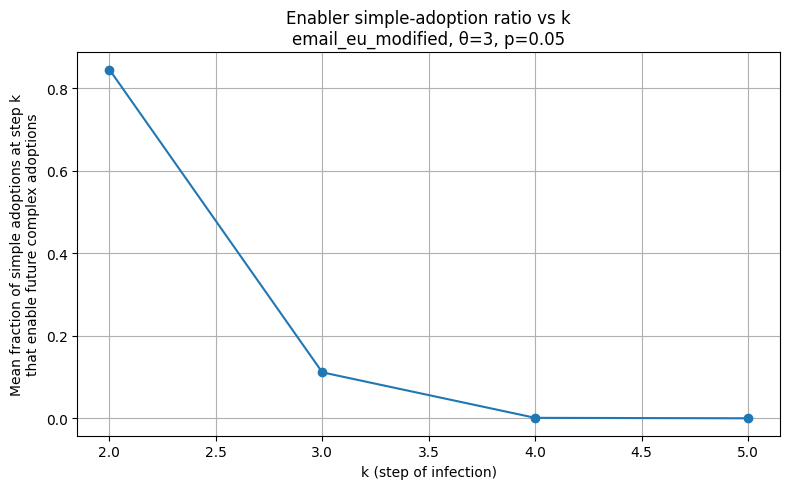

In [185]:
import matplotlib.pyplot as plt

network_name = "email_eu_modified"
theta = 3
prob_complex = 0.05
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

ratio_df = simple_enabler_ratio_over_k(network_name, theta, prob_complex, k_values)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ratio_df["k"],
    ratio_df["mean_enabler_ratio"],
    marker="o"
)

ax.set_xlabel("k (step of infection)")
ax.set_ylabel("Mean fraction of simple adoptions at step k\nthat enable future complex adoptions")
ax.set_title(f"Enabler simple-adoption ratio vs k\n{network_name}, θ={theta}, p={prob_complex}")
ax.grid(True)

plt.tight_layout()
plt.show()


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),


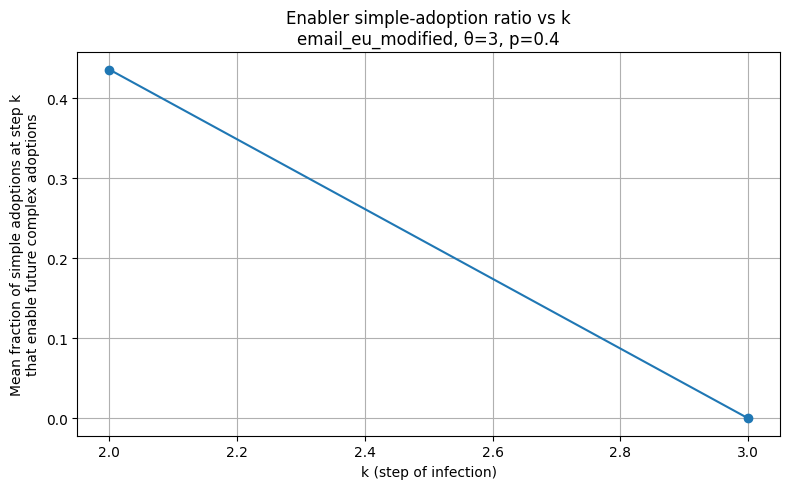

In [187]:
import matplotlib.pyplot as plt

network_name = "email_eu_modified"
theta = 3
prob_complex = 0.4
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

ratio_df = simple_enabler_ratio_over_k(network_name, theta, prob_complex, k_values)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    ratio_df["k"],
    ratio_df["mean_enabler_ratio"],
    marker="o"
)

ax.set_xlabel("k (step of infection)")
ax.set_ylabel("Mean fraction of simple adoptions at step k\nthat enable future complex adoptions")
ax.set_title(f"Enabler simple-adoption ratio vs k\n{network_name}, θ={theta}, p={prob_complex}")
ax.grid(True)

plt.tight_layout()
plt.show()

/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var

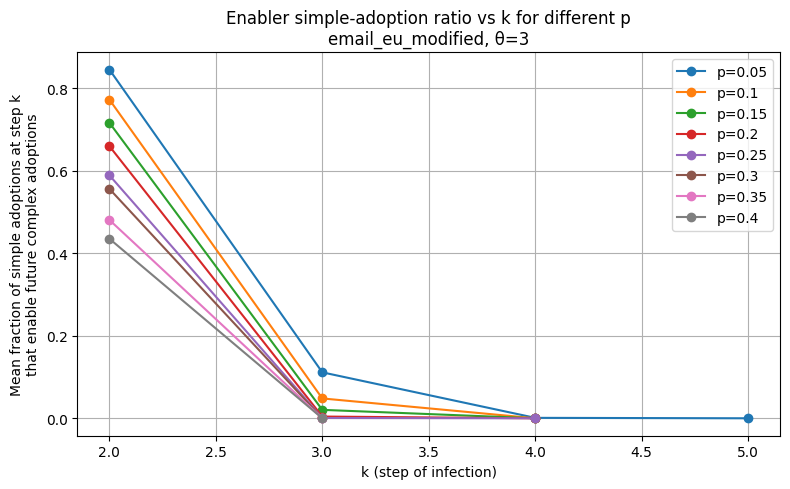

In [189]:
# Enabler simple-adoption ratio vs k for different prob_complex values

import matplotlib.pyplot as plt

network_name = "email_eu_modified"
theta = 3
prob_complexes = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

fig, ax = plt.subplots(figsize=(8, 5))

for prob_complex in prob_complexes:
    ratio_df = simple_enabler_ratio_over_k(
        network_name=network_name,
        theta=theta,
        prob_complex=prob_complex,
        k_values=k_values
    )
    
    ax.plot(
        ratio_df["k"],
        ratio_df["mean_enabler_ratio"],
        marker="o",
        label=f"p={prob_complex}"
    )

ax.set_xlabel("k (step of infection)")
ax.set_ylabel("Mean fraction of simple adoptions at step k\nthat enable future complex adoptions")
ax.set_title(f"Enabler simple-adoption ratio vs k for different p\n{network_name}, θ={theta}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/2670679353.py:106: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanme

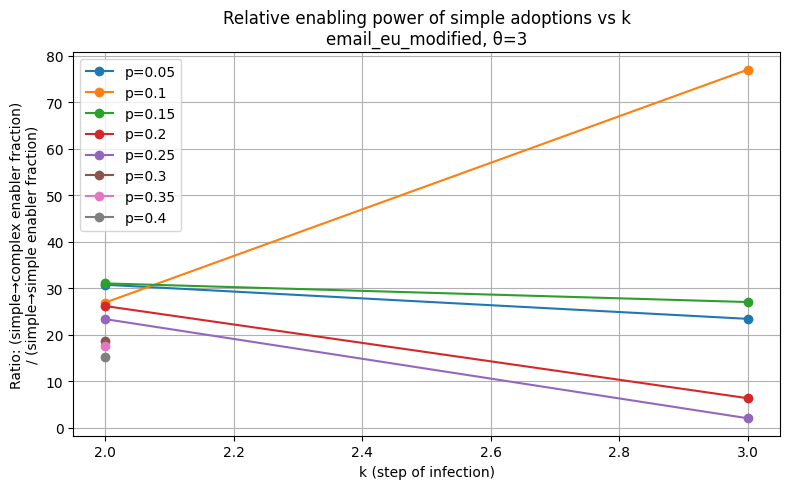

In [199]:
import numpy as np
import matplotlib.pyplot as plt

network_name = "email_eu_modified"
theta = 3
prob_complexes = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

fig, ax = plt.subplots(figsize=(8, 5))

for prob_complex in prob_complexes:
    # Plot 1: simple -> future complex
    df_sc = simple_enabler_ratio_over_k(
        network_name=network_name,
        theta=theta,
        prob_complex=prob_complex,
        k_values=k_values
    )  # columns: k, mean_enabler_ratio, ...

    # Plot 2: simple -> future simple
    df_ss = simple_enabler_simple_ratio_over_k(
        network_name=network_name,
        theta=theta,
        prob_complex=prob_complex,
        k_values=k_values
    )  # columns: k, mean_enabler_ratio_simple, ...

    # Merge on k
    merged = df_sc.merge(df_ss, on="k", how="inner")

    # Compute ratio (simple→complex / simple→simple)
    # Avoid division by zero by treating 0 as NaN
    num = merged["mean_enabler_ratio"].to_numpy(dtype=float)
    den = merged["mean_enabler_ratio_simple"].to_numpy(dtype=float)

    den_safe = np.where(den == 0, np.nan, den)
    ratio = num / den_safe

    ax.plot(
        merged["k"],
        ratio,
        marker="o",
        label=f"p={prob_complex}"
    )

ax.set_xlabel("k (step of infection)")
ax.set_ylabel(
    "Ratio: (simple→complex enabler fraction)\n"
    "/ (simple→simple enabler fraction)"
)
ax.set_title(
    f"Relative enabling power of simple adoptions vs k\n"
    f"{network_name}, θ={theta}"
)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


In [201]:
merged

,k,mean_enabler_ratio,mean_num_simple_at_k_x,mean_num_enabler_simple_at_k_x,mean_enabler_ratio_simple,mean_num_simple_at_k_y,mean_num_enabler_simple_at_k_y
0,2,0.435529,85.98,39.25,0.028593,85.98,2.54
1,3,0.000000,46.42,0.00,0.000000,46.42,0.00
2,4,NaN,0.00,0.00,NaN,0.00,0.00
3,5,NaN,0.00,0.00,NaN,0.00,0.00
4,6,NaN,0.00,0.00,NaN,0.00,0.00
5,7,NaN,0.00,0.00,NaN,0.00,0.00
6,8,NaN,0.00,0.00,NaN,0.00,0.00
7,9,NaN,0.00,0.00,NaN,0.00,0.00
8,10,NaN,0.00,0.00,NaN,0.00,0.00


In [191]:
def simple_enabler_simple_ratio_over_k(network_name, theta, prob_complex, k_values):
    """
    For a given (network, theta, prob), compute for each k in k_values the
    fraction of simple adoptions at step k that later enable at least one
    *simple* adoption in a neighbor.

    A node i is counted as an "enabler simple adoption" if:
      - it adopted via simple (type == 2) at time t_i, and
      - it has at least one neighbor j that adopted via simple (type == 2)
        at a later time t_j > t_i.

    Returns
    -------
    result_df : pd.DataFrame with columns:
        k, mean_enabler_ratio_simple,
           mean_num_simple_at_k,
           mean_num_enabler_simple_at_k
    """
    # Load data
    df_order, df_type = load_complex_and_infection_type(network_name, theta, prob_complex)
    G = load_graph_for_network(network_name)

    # Align node ordering between graph and CSV columns
    node_cols = get_node_columns(df_order)
    node_cols_type = get_node_columns(df_type)
    if node_cols != node_cols_type:
        raise ValueError("Node columns in order and infection_type CSVs do not match.")

    node_list = np.array(list(G.nodes()))
    if len(node_list) != len(node_cols):
        raise ValueError("Number of graph nodes and node columns differ.")

    # Map node id -> index
    node_to_idx = {node: idx for idx, node in enumerate(node_list)}

    # Precompute neighbor indices for each node index
    neighbors_idx = []
    for i, node in enumerate(node_list):
        neighs = [node_to_idx[nbr] for nbr in G.neighbors(node)]
        neighbors_idx.append(np.array(neighs, dtype=int))

    order_vals = df_order[node_cols].to_numpy(dtype=float)
    type_vals = df_type[node_cols].to_numpy(dtype=float)

    n_sims, n_nodes = order_vals.shape

    rows = []

    for k in k_values:
        ratios_k = []
        simple_counts_k = []
        enabler_simple_counts_k = []

        for s in range(n_sims):
            steps = order_vals[s, :]   # infection time per node (NaN if never)
            types = type_vals[s, :]    # 0=seed/none, 1=complex, 2=simple

            # --- 1) Mark simple nodes that enable *future simple* adoptions ---
            enabler_simple = np.zeros(n_nodes, dtype=bool)

            # Loop over simple adopters (future ones)
            for j in range(n_nodes):
                if np.isnan(steps[j]):
                    continue
                if types[j] != 2:  # not simple adoption
                    continue

                t_j = steps[j]
                # Look at neighbors infected before this simple adoption
                for i in neighbors_idx[j]:
                    if np.isnan(steps[i]):
                        continue
                    if types[i] == 2 and steps[i] < t_j:
                        enabler_simple[i] = True

            # --- 2) Restrict to simple adoptions happening exactly at step k ---
            is_simple_at_k = (types == 2) & (~np.isnan(steps)) & (steps == k)

            num_simple_k = np.sum(is_simple_at_k)
            num_enabler_simple_k = np.sum(is_simple_at_k & enabler_simple)

            simple_counts_k.append(num_simple_k)
            enabler_simple_counts_k.append(num_enabler_simple_k)

            if num_simple_k > 0:
                ratios_k.append(num_enabler_simple_k / num_simple_k)
            else:
                ratios_k.append(np.nan)

        rows.append({
            "k": k,
            "mean_enabler_ratio_simple": np.nanmean(ratios_k),
            "mean_num_simple_at_k": np.mean(simple_counts_k),
            "mean_num_enabler_simple_at_k": np.mean(enabler_simple_counts_k),
        })

    return pd.DataFrame(rows)


/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio_simple": np.nanmean(ratios_k),
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_36535/1686207099.py:92: RuntimeWarning: Mean of empty slice
  "mean_enabler_ratio

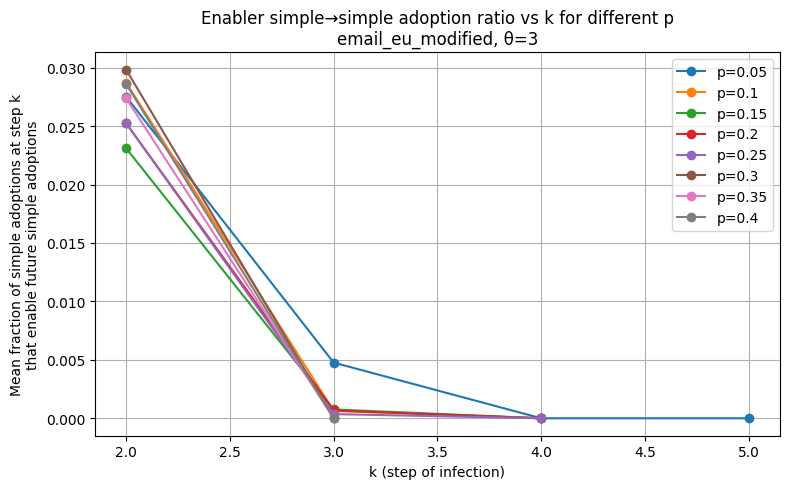

In [197]:
import matplotlib.pyplot as plt

network_name = "email_eu_modified"
theta = 3
prob_complexes = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

fig, ax = plt.subplots(figsize=(8, 5))

for prob_complex in prob_complexes:
    ratio_df = simple_enabler_simple_ratio_over_k(
        network_name=network_name,
        theta=theta,
        prob_complex=prob_complex,
        k_values=k_values
    )
    
    ax.plot(
        ratio_df["k"],
        ratio_df["mean_enabler_ratio_simple"],
        marker="o",
        label=f"p={prob_complex}"
    )

ax.set_xlabel("k (step of infection)")
ax.set_ylabel("Mean fraction of simple adoptions at step k\nthat enable future simple adoptions")
ax.set_title(f"Enabler simple→simple adoption ratio vs k for different p\n{network_name}, θ={theta}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


In [173]:
import numpy as np

def infected_counts_over_k(df_order, df_type, k_values):
    """
    For each k in k_values, compute the mean number of nodes infected via
    simple vs complex mechanisms up to step k (averaged over simulations).

    Returns
    -------
    result_df : pd.DataFrame with columns:
        k, mean_simple_count, mean_complex_count, mean_total_infected
    """
    node_cols_order = get_node_columns(df_order)
    node_cols_type = get_node_columns(df_type)

    if node_cols_order != node_cols_type:
        raise ValueError("Node columns in order and infection_type CSVs do not match.")

    order_vals = df_order[node_cols_order].to_numpy(dtype=float)
    type_vals = df_type[node_cols_type].to_numpy(dtype=float)

    n_sims, n_nodes = order_vals.shape

    rows = []
    for k in k_values:
        simple_counts = []
        complex_counts = []
        total_counts = []

        for i in range(n_sims):
            steps = order_vals[i, :]   # infection time (NaN for never infected)
            types = type_vals[i, :]    # 0 (seed/none), 1 (complex), 2 (simple)

            # nodes infected by step <= k
            mask = (~np.isnan(steps)) & (steps <= k)

            simple_count = np.sum((types == 2) & mask)
            complex_count = np.sum((types == 1) & mask)
            total_count = np.sum(mask)  # includes seeds + any untyped if you had them

            simple_counts.append(simple_count)
            complex_counts.append(complex_count)
            total_counts.append(total_count)

        rows.append({
            "k": k,
            "mean_simple_count": np.mean(simple_counts),
            "mean_complex_count": np.mean(complex_counts),
            "mean_total_infected": np.mean(total_counts),
        })

    return pd.DataFrame(rows)


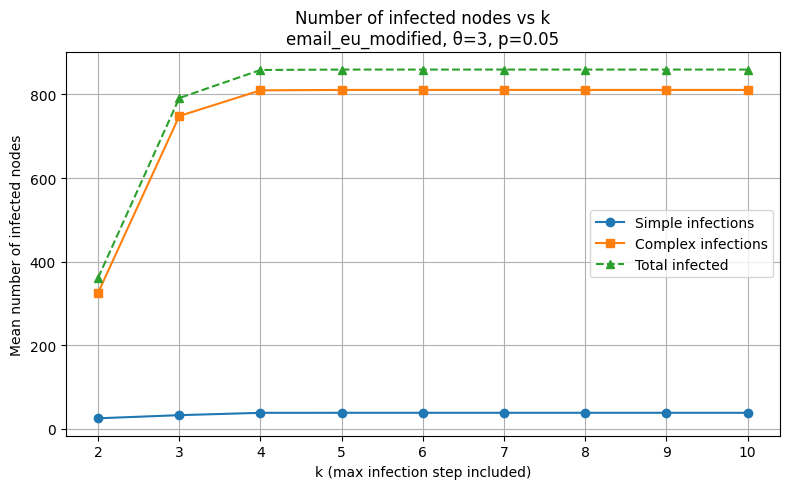

In [177]:
import matplotlib.pyplot as plt

# Parameters you want to inspect
network_name = "email_eu_modified"
theta = 3
prob_complex = 0.05
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Load base + infection_type CSVs
df_order, df_type = load_complex_and_infection_type(network_name, theta, prob_complex)

# Compute mean counts over k
counts_df = infected_counts_over_k(df_order, df_type, k_values)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    counts_df["k"],
    counts_df["mean_simple_count"],
    marker="o",
    label="Simple infections"
)

ax.plot(
    counts_df["k"],
    counts_df["mean_complex_count"],
    marker="s",
    label="Complex infections"
)

# Optional: also plot total infected (simple + complex + seeds)
ax.plot(
    counts_df["k"],
    counts_df["mean_total_infected"],
    marker="^",
    linestyle="--",
    label="Total infected"
)

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean number of infected nodes")
ax.set_title(f"Number of infected nodes vs k\n{network_name}, θ={theta}, p={prob_complex}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


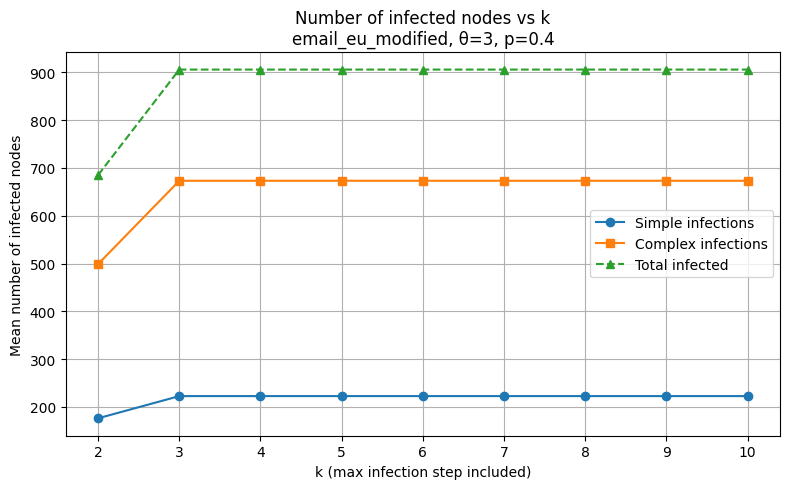

In [179]:
import matplotlib.pyplot as plt

# Parameters you want to inspect
network_name = "email_eu_modified"
theta = 3
prob_complex = 0.4
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Load base + infection_type CSVs
df_order, df_type = load_complex_and_infection_type(network_name, theta, prob_complex)

# Compute mean counts over k
counts_df = infected_counts_over_k(df_order, df_type, k_values)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    counts_df["k"],
    counts_df["mean_simple_count"],
    marker="o",
    label="Simple infections"
)

ax.plot(
    counts_df["k"],
    counts_df["mean_complex_count"],
    marker="s",
    label="Complex infections"
)

# Optional: also plot total infected (simple + complex + seeds)
ax.plot(
    counts_df["k"],
    counts_df["mean_total_infected"],
    marker="^",
    linestyle="--",
    label="Total infected"
)

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean number of infected nodes")
ax.set_title(f"Number of infected nodes vs k\n{network_name}, θ={theta}, p={prob_complex}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Plot EPH vs k for different prob_complex values (each prob = different color)

import matplotlib.pyplot as plt

network_name = "email_eu_modified"      # change if needed
theta = 2                               # fix one theta for this plot
prob_complexes = [0.2, 0.3, 0.4, 0.5]   # the prob_complex values you want to compare
k_values = [1, 2, 3, 4, 5, 6, 7, 8]     # the k values you want on the x-axis
network_name = "email_eu_modified"   # change if needed
thetas = [2, 3, 4, 5]                # the theta values you want to compare
prob_complex = 0.02                  # fix one prob_complex for this plot
k_values = [ 2, 3, 4, 5, 6, 7, 8, 9, 10]  # the k values you want on the x-axis



fig, ax = plt.subplots(figsize=(8, 5))

for prob_complex in prob_complexes:
    # summary_curr has columns: k, mean_EPH, EPH_CI_lower, EPH_CI_upper, ...
    summary_curr = build_summary_over_k(
        network_name=network_name,
        theta=theta,
        prob_complex=prob_complex,
        k_values=k_values,
        alpha=0.05
    )
    
    # Plot mean EPH vs k for this prob_complex
    ax.plot(
        summary_curr["k"],
        summary_curr["mean_EPH"],
        marker="o",
        label=f"p={prob_complex}"
    )

ax.set_xlabel("k (max infection step included)")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs k for different p values\n{network_name}, θ={theta}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


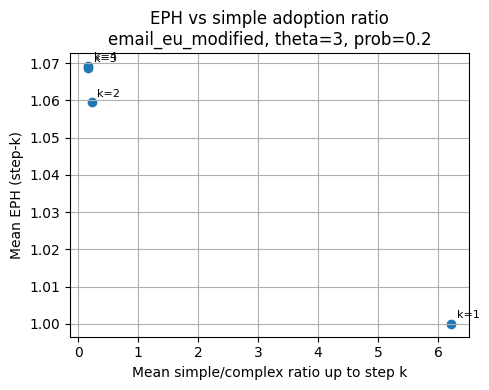

In [19]:
# Cell C: EPH vs simple/complex ratio (one point per k)

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(summary_df["mean_simple_ratio"], summary_df["mean_EPH"])

for _, row in summary_df.iterrows():
    ax.annotate(
        f"k={int(row['k'])}",
        (row["mean_simple_ratio"], row["mean_EPH"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8
    )

ax.set_xlabel("Mean simple/complex ratio up to step k")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs simple adoption ratio\n{network_name}, theta={theta}, prob={prob_complex}")
ax.grid(True)

plt.tight_layout()
plt.show()


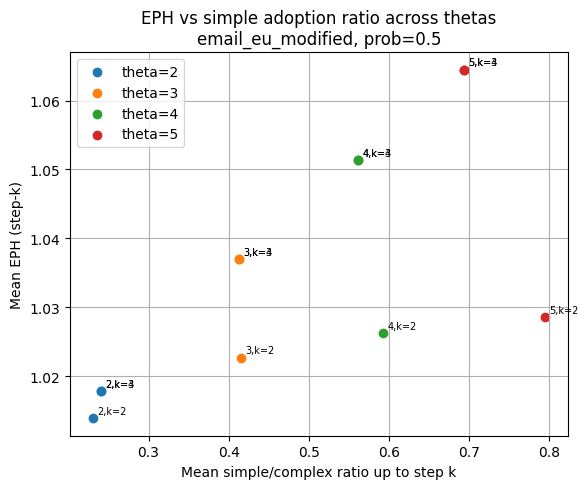

In [21]:
# Cell D: compare multiple thetas on EPH vs ratio plane for a fixed prob and network

# thetas = [2, 3, 4, 5]
# prob_complex = 0.02
# k_values = [1, 2, 3, 4, 5, 6, 7, 8]

network_name = "email_eu_modified"
thetas = [2, 3, 4, 5]
prob_complex = 0.5
k_values = [ 2, 3, 4]

fig, ax = plt.subplots(figsize=(6, 5))

for theta_curr in thetas:
    summary_curr = build_summary_over_k(network_name, theta_curr, prob_complex, k_values)
    ax.scatter(summary_curr["mean_simple_ratio"], summary_curr["mean_EPH"], label=f"theta={theta_curr}")
    # Optionally annotate only a few ks if it gets messy
    for _, row in summary_curr.iterrows():
        ax.annotate(
            f"{theta_curr},k={int(row['k'])}",
            (row["mean_simple_ratio"], row["mean_EPH"]),
            textcoords="offset points",
            xytext=(3, 3),
            fontsize=7
        )

ax.set_xlabel("Mean simple/complex ratio up to step k")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs simple adoption ratio across thetas\n{network_name}, prob={prob_complex}")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


## 
1. more points (higher k values)
2. 

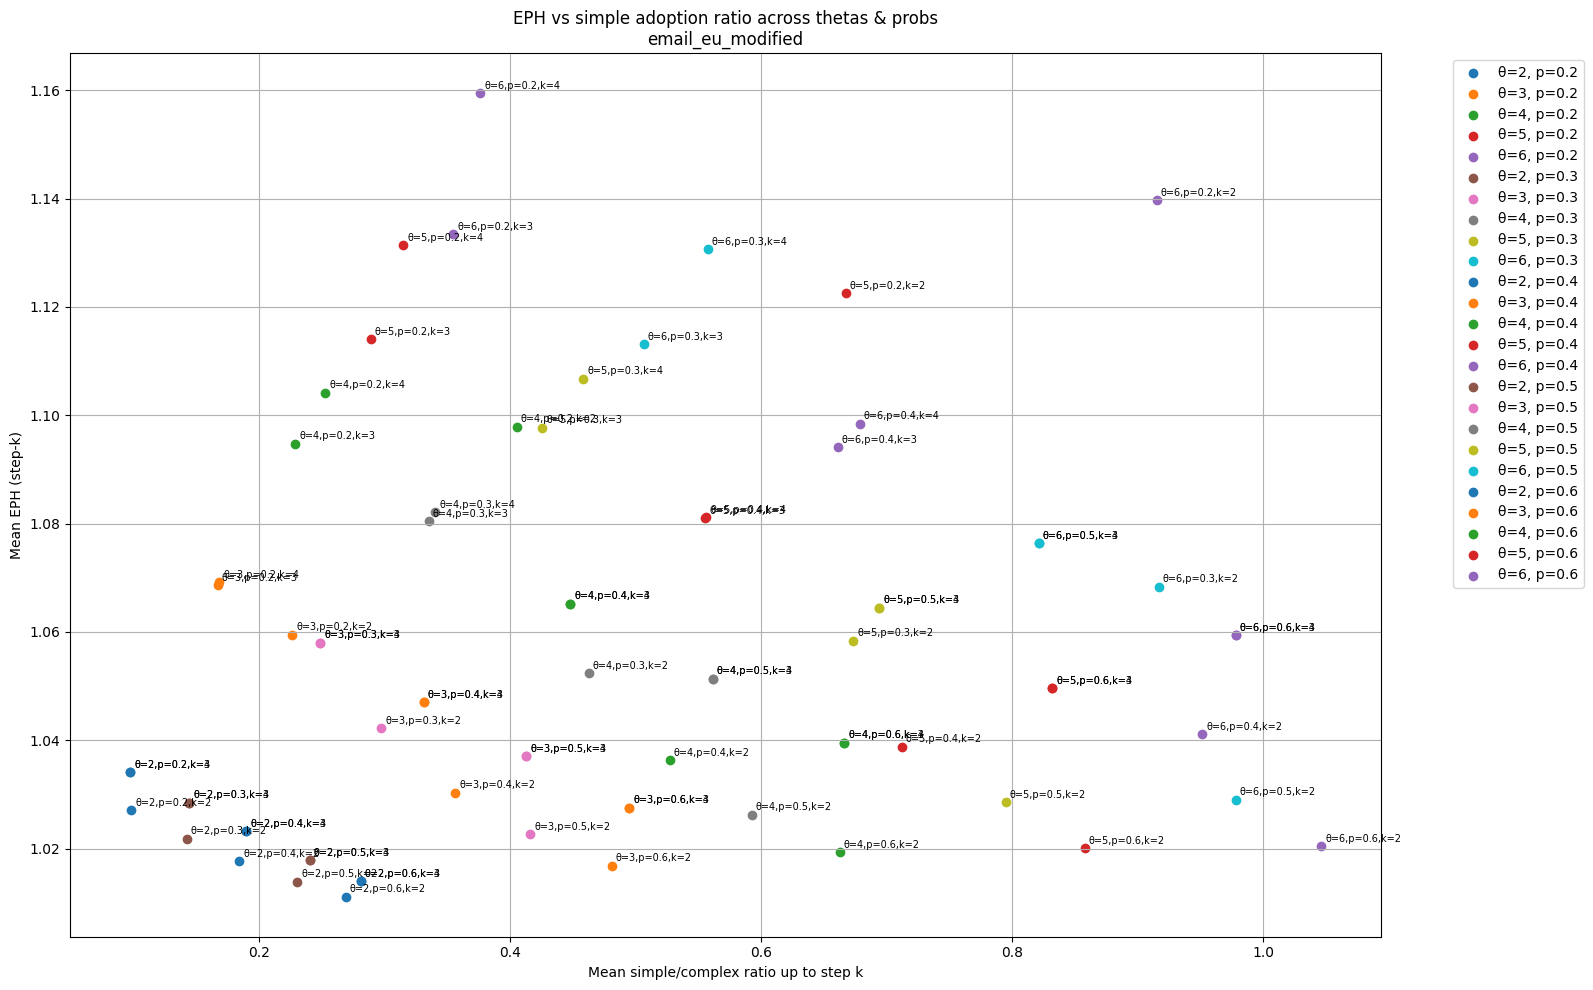

In [23]:
# Cell D (updated): compare multiple thetas *and* multiple probs
# on EPH vs ratio plane for a fixed network

network_name = "email_eu_modified"
thetas = [2, 3, 4, 5, 6]
prob_complexes = [0.2,0.3,0.4,0.5,0.6] # <-- now a set/list
k_values = [2, 3, 4]

fig, ax = plt.subplots(figsize=(16, 10))

for prob_complex in prob_complexes:
    for theta_curr in thetas:
        summary_curr = build_summary_over_k(network_name, theta_curr, prob_complex, k_values)
        # one point per k for this (theta, prob)
        ax.scatter(
            summary_curr["mean_simple_ratio"],
            summary_curr["mean_EPH"],
            label=f"θ={theta_curr}, p={prob_complex}"
        )
        # annotate each point with k (and optionally prob/theta if you want)
        for _, row in summary_curr.iterrows():
            ax.annotate(
                f"θ={theta_curr},p={prob_complex},k={int(row['k'])}",
                (row["mean_simple_ratio"], row["mean_EPH"]),
                textcoords="offset points",
                xytext=(3, 3),
                fontsize=7
            )

ax.set_xlabel("Mean simple/complex ratio up to step k")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs simple adoption ratio across thetas & probs\n{network_name}")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside if it gets crowded

plt.tight_layout()
plt.show()


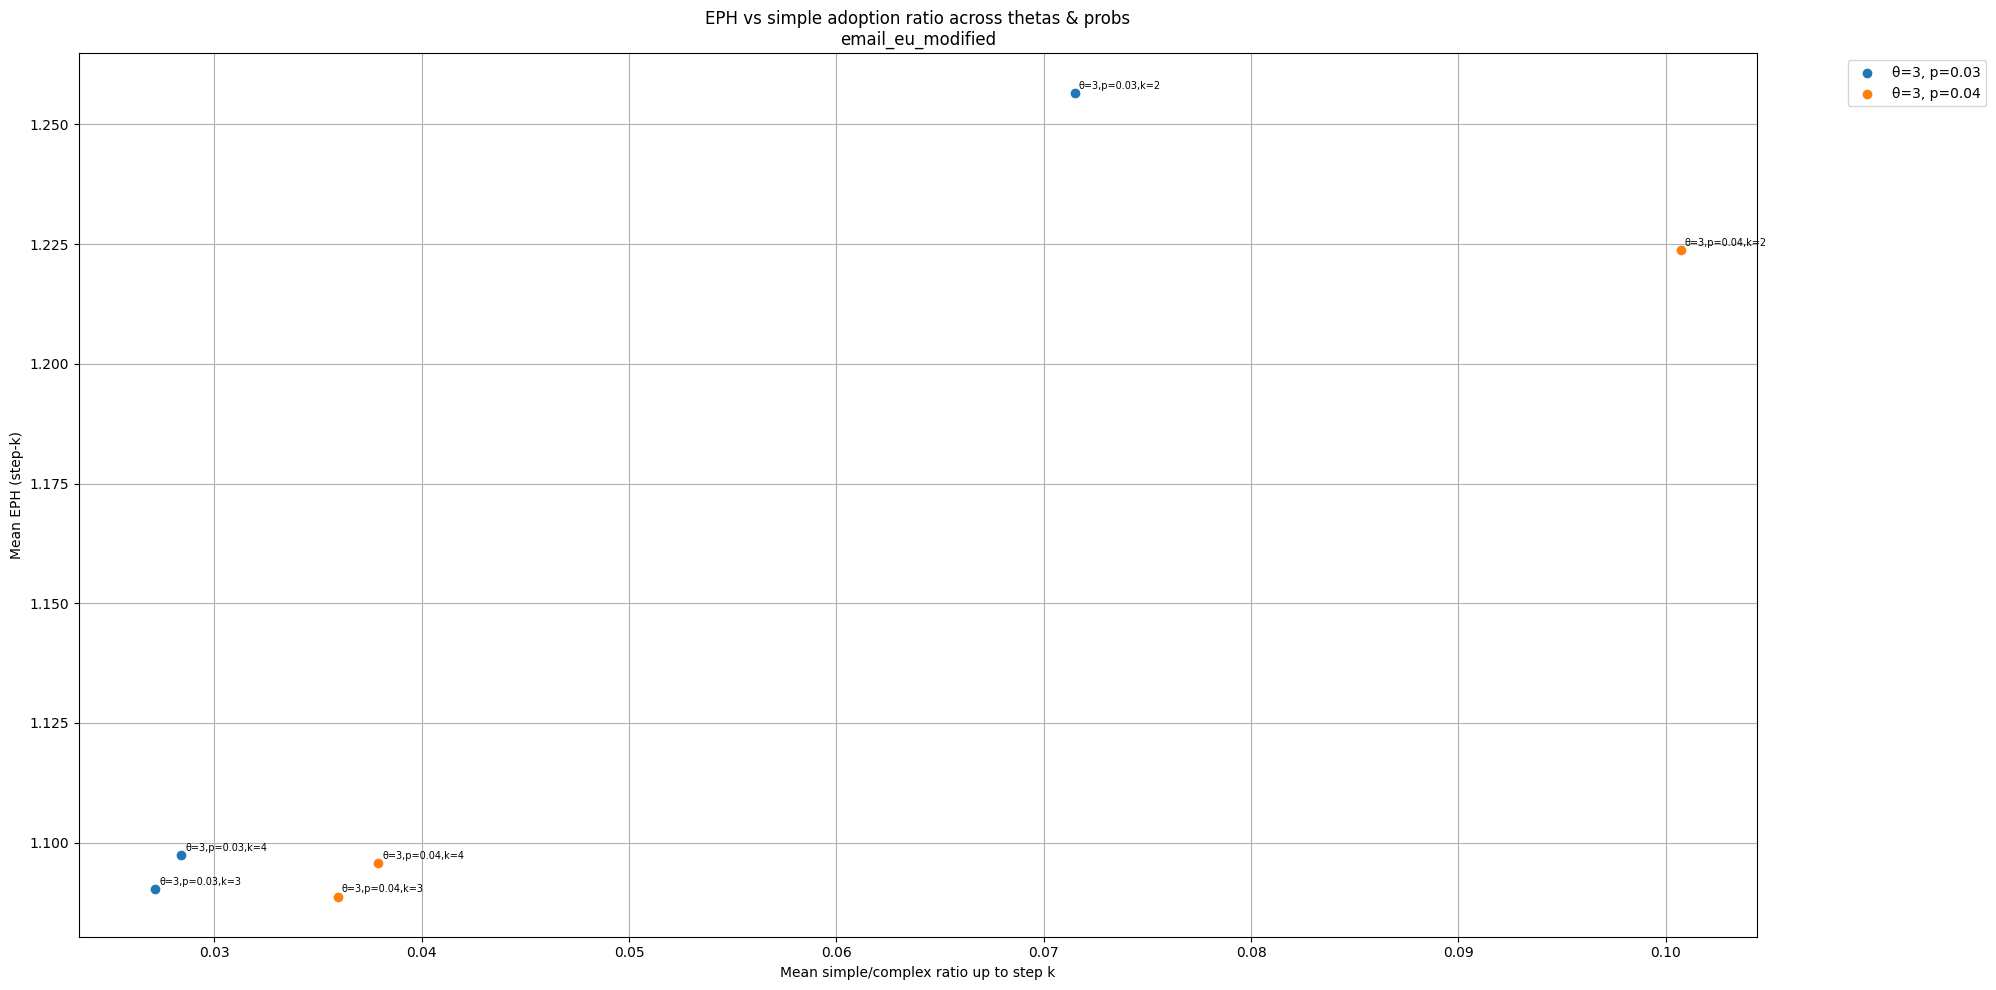

In [75]:
# Cell D (updated): compare multiple thetas *and* multiple probs
# on EPH vs ratio plane for a fixed network

network_name = "email_eu_modified"
thetas = [3]
prob_complexes = [0.03,0.04] # <-- now a set/list
k_values = [2,3,4]

fig, ax = plt.subplots(figsize=(20, 10))

for prob_complex in prob_complexes:
    for theta_curr in thetas:
        summary_curr = build_summary_over_k(network_name, theta_curr, prob_complex, k_values)
        # one point per k for this (theta, prob)
        ax.scatter(
            summary_curr["mean_simple_ratio"],
            summary_curr["mean_EPH"],
            label=f"θ={theta_curr}, p={prob_complex}"
        )
        # annotate each point with k (and optionally prob/theta if you want)
        for _, row in summary_curr.iterrows():
            ax.annotate(
                f"θ={theta_curr},p={prob_complex},k={int(row['k'])}",
                (row["mean_simple_ratio"], row["mean_EPH"]),
                textcoords="offset points",
                xytext=(3, 3),
                fontsize=7
            )

ax.set_xlabel("Mean simple/complex ratio up to step k")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs simple adoption ratio across thetas & probs\n{network_name}")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside if it gets crowded

plt.tight_layout()
plt.show()


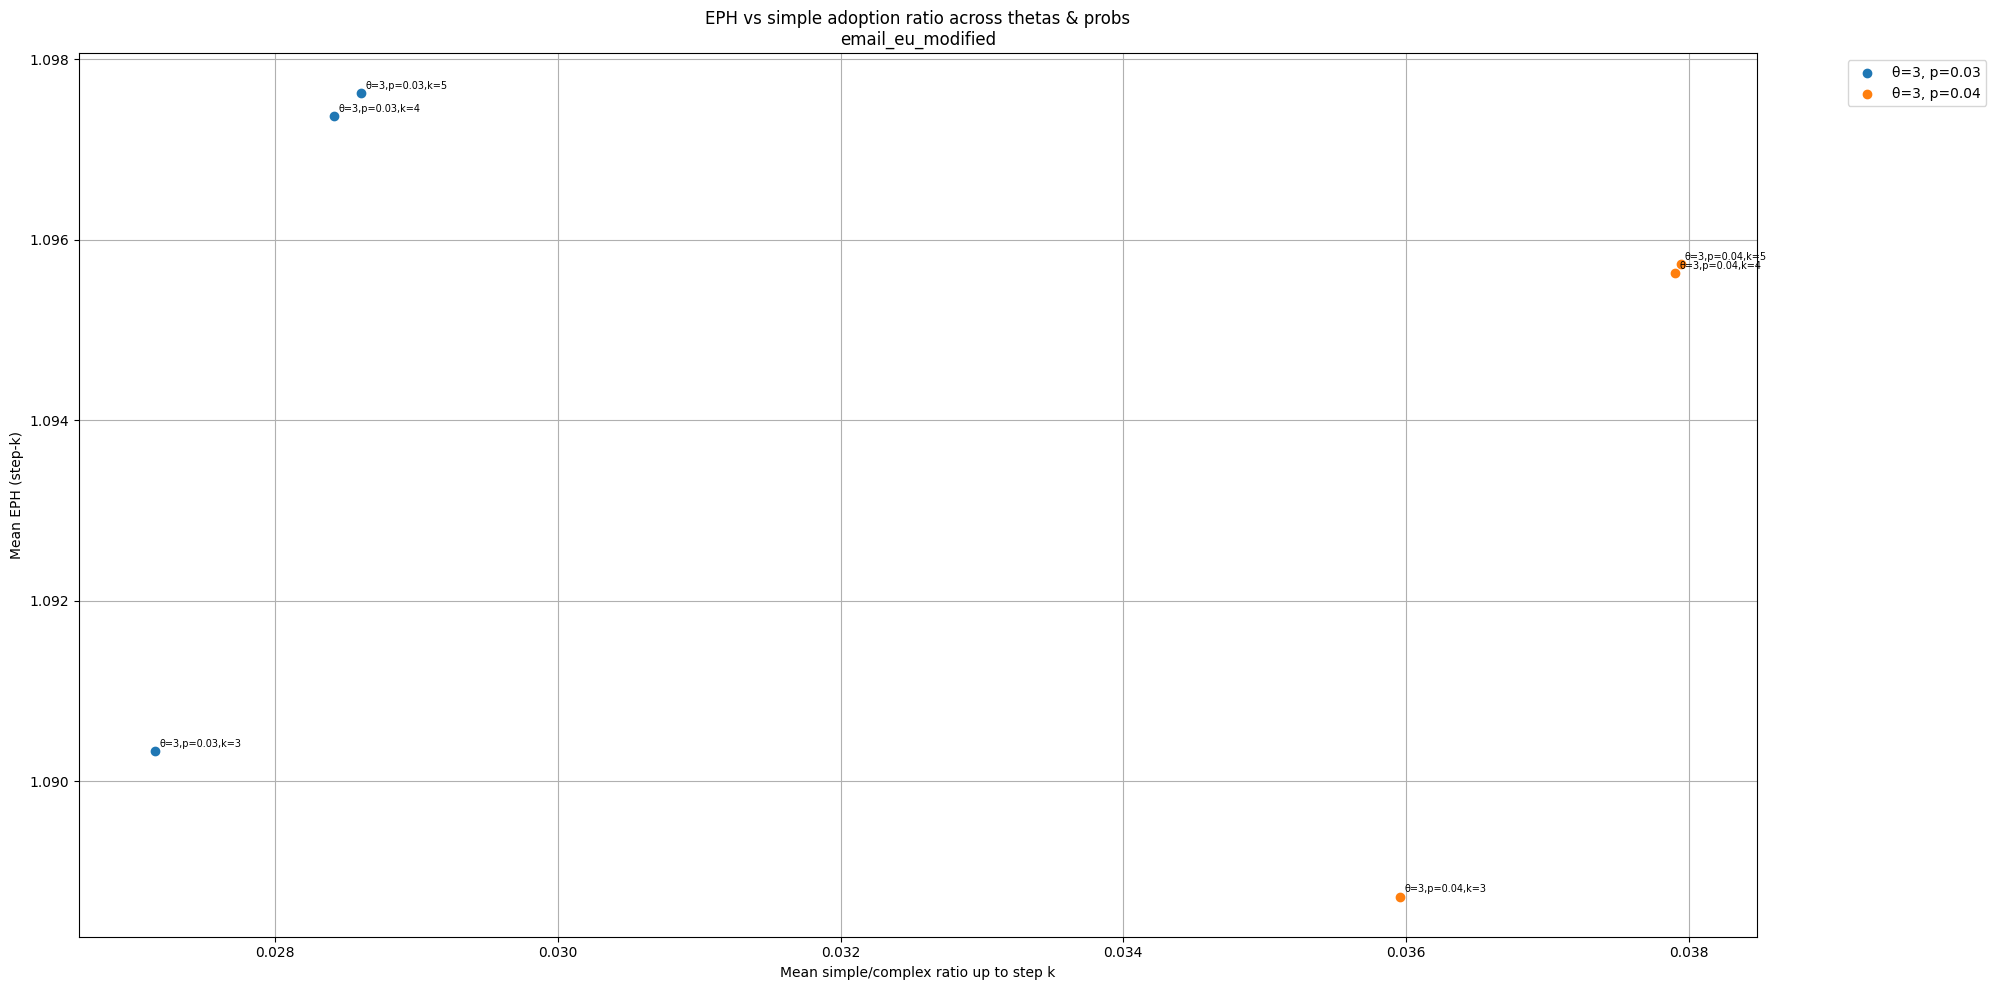

In [87]:
# Cell D (updated): compare multiple thetas *and* multiple probs
# on EPH vs ratio plane for a fixed network

network_name = "email_eu_modified"
thetas = [3]
prob_complexes = [0.03,0.04] # <-- now a set/list
k_values = [3,4,5]

fig, ax = plt.subplots(figsize=(20, 10))

for prob_complex in prob_complexes:
    for theta_curr in thetas:
        summary_curr = build_summary_over_k(network_name, theta_curr, prob_complex, k_values)
        # one point per k for this (theta, prob)
        ax.scatter(
            summary_curr["mean_simple_ratio"],
            summary_curr["mean_EPH"],
            label=f"θ={theta_curr}, p={prob_complex}"
        )
        # annotate each point with k (and optionally prob/theta if you want)
        for _, row in summary_curr.iterrows():
            ax.annotate(
                f"θ={theta_curr},p={prob_complex},k={int(row['k'])}",
                (row["mean_simple_ratio"], row["mean_EPH"]),
                textcoords="offset points",
                xytext=(3, 3),
                fontsize=7
            )

ax.set_xlabel("Mean simple/complex ratio up to step k")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs simple adoption ratio across thetas & probs\n{network_name}")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside if it gets crowded

plt.tight_layout()
plt.show()


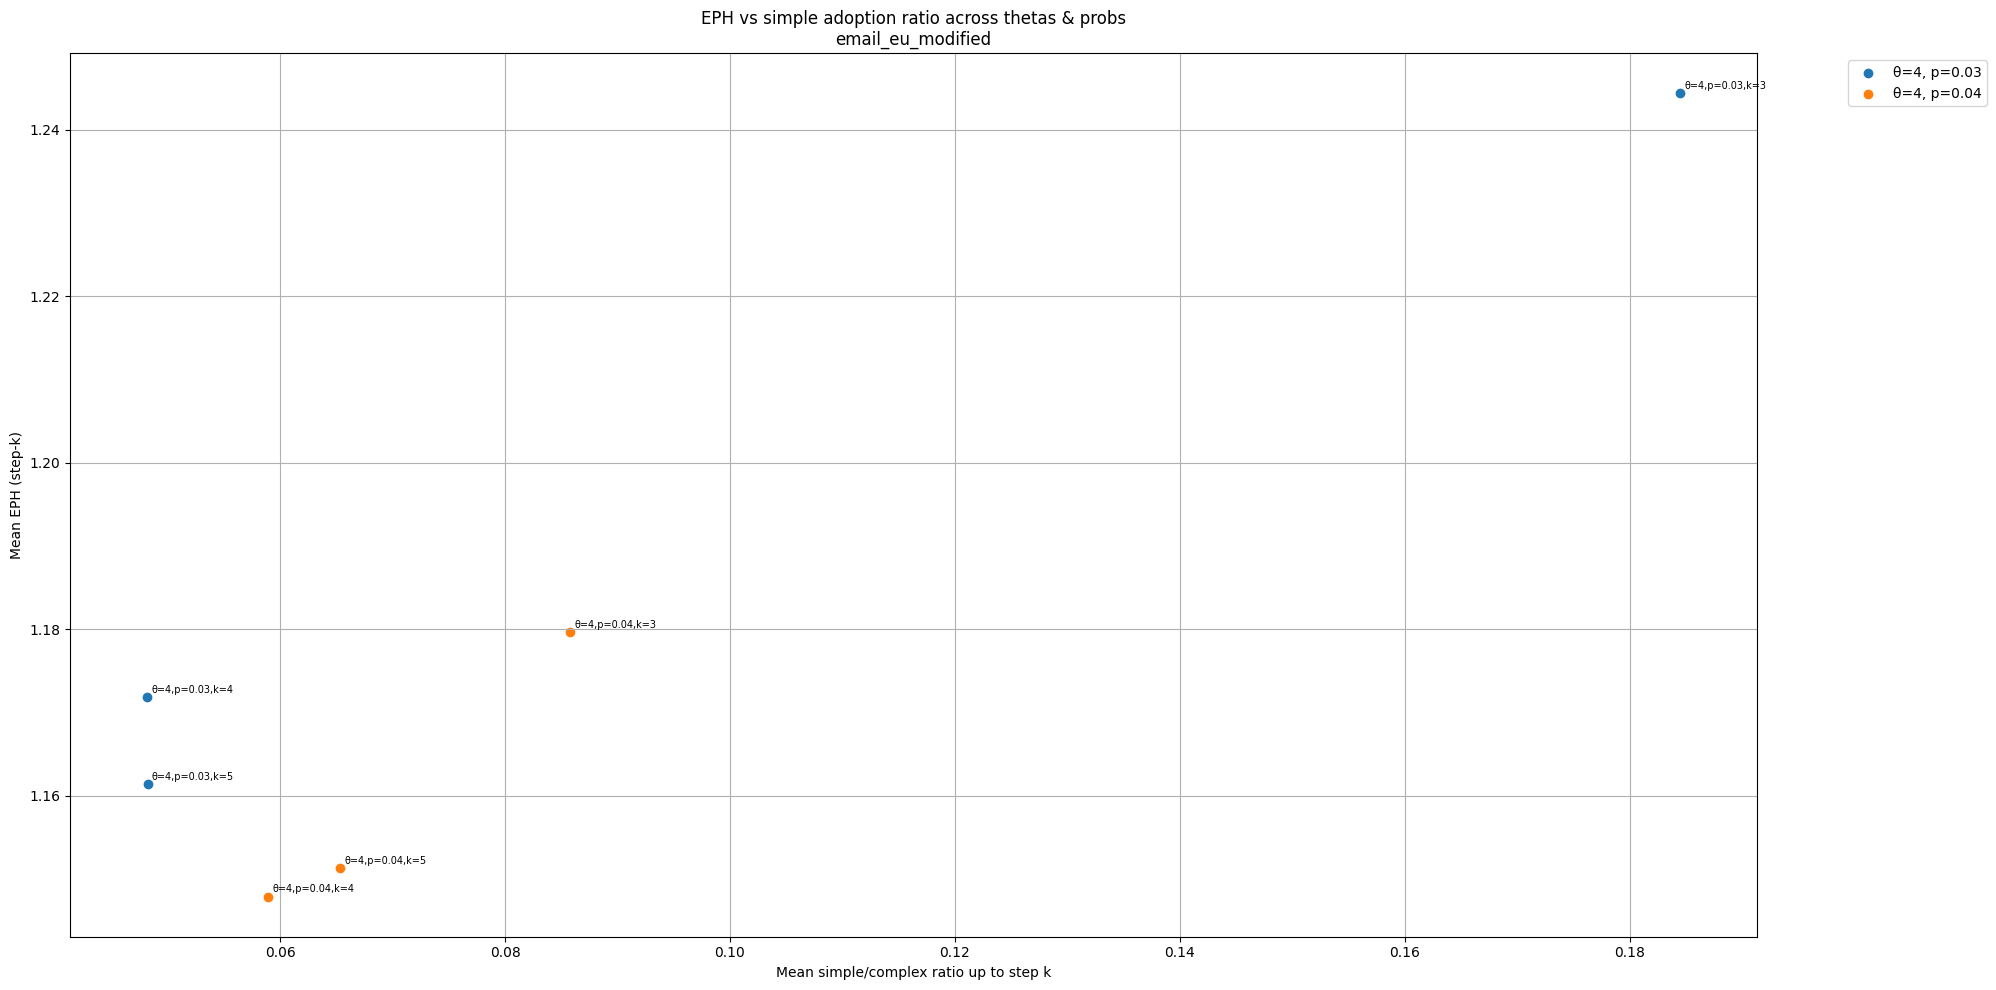

In [89]:
# Cell D (updated): compare multiple thetas *and* multiple probs
# on EPH vs ratio plane for a fixed network

network_name = "email_eu_modified"
thetas = [4]
prob_complexes = [0.03,0.04] # <-- now a set/list
k_values = [3,4,5]

fig, ax = plt.subplots(figsize=(20, 10))

for prob_complex in prob_complexes:
    for theta_curr in thetas:
        summary_curr = build_summary_over_k(network_name, theta_curr, prob_complex, k_values)
        # one point per k for this (theta, prob)
        ax.scatter(
            summary_curr["mean_simple_ratio"],
            summary_curr["mean_EPH"],
            label=f"θ={theta_curr}, p={prob_complex}"
        )
        # annotate each point with k (and optionally prob/theta if you want)
        for _, row in summary_curr.iterrows():
            ax.annotate(
                f"θ={theta_curr},p={prob_complex},k={int(row['k'])}",
                (row["mean_simple_ratio"], row["mean_EPH"]),
                textcoords="offset points",
                xytext=(3, 3),
                fontsize=7
            )

ax.set_xlabel("Mean simple/complex ratio up to step k")
ax.set_ylabel("Mean EPH (step-k)")
ax.set_title(f"EPH vs simple adoption ratio across thetas & probs\n{network_name}")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # move legend outside if it gets crowded

plt.tight_layout()
plt.show()


In [79]:
def final_simple_ratio_ci(network_name, theta, prob_complex, alpha=0.05):
    """
    Get the mean and CI of the *final* simple/complex ratio over the whole process,
    using the 'simple_infection_ratio' column from the complex contagion CSV.
    """
    df_order, _ = load_complex_and_infection_type(network_name, theta, prob_complex)
    if "simple_infection_ratio" not in df_order.columns:
        raise ValueError("Column 'simple_infection_ratio' not found in base CSV.")

    ratios = df_order["simple_infection_ratio"].to_numpy(dtype=float)
    mean, lower, upper = mean_confidence_interval(ratios, alpha=alpha)
    return {
        "network": network_name,
        "theta": theta,
        "prob_complex": prob_complex,
        "mean_simple_ratio": mean,
        "CI_lower": lower,
        "CI_upper": upper,
    }


In [81]:
def build_summary_over_k_with_final_ratio(network_name, theta, prob_complex, k_values, alpha=0.05):
    """
    For a given (network, theta, prob), compute:
      - EPH (mean ± CI) for each k,
      - final simple/complex ratio (mean ± CI), same for all k.

    Returns
    -------
    DataFrame with columns:
      k, mean_EPH, EPH_CI_lower, EPH_CI_upper,
      mean_final_simple_ratio, final_ratio_CI_lower, final_ratio_CI_upper
    """
    # EPH per k (same as before)
    rows = []
    for k in k_values:
        eph_ci = eph_ci_for_step_k(network_name, theta, prob_complex, k, alpha=alpha)
        rows.append({
            "k": k,
            "mean_EPH": eph_ci["mean_EPH"],
            "EPH_CI_lower": eph_ci["CI_lower"],
            "EPH_CI_upper": eph_ci["CI_upper"],
        })
    df = pd.DataFrame(rows)

    # Final ratio (independent of k)
    ratio_ci = final_simple_ratio_ci(network_name, theta, prob_complex, alpha=alpha)
    df["mean_final_simple_ratio"] = ratio_ci["mean_simple_ratio"]
    df["final_ratio_CI_lower"] = ratio_ci["CI_lower"]
    df["final_ratio_CI_upper"] = ratio_ci["CI_upper"]

    return df


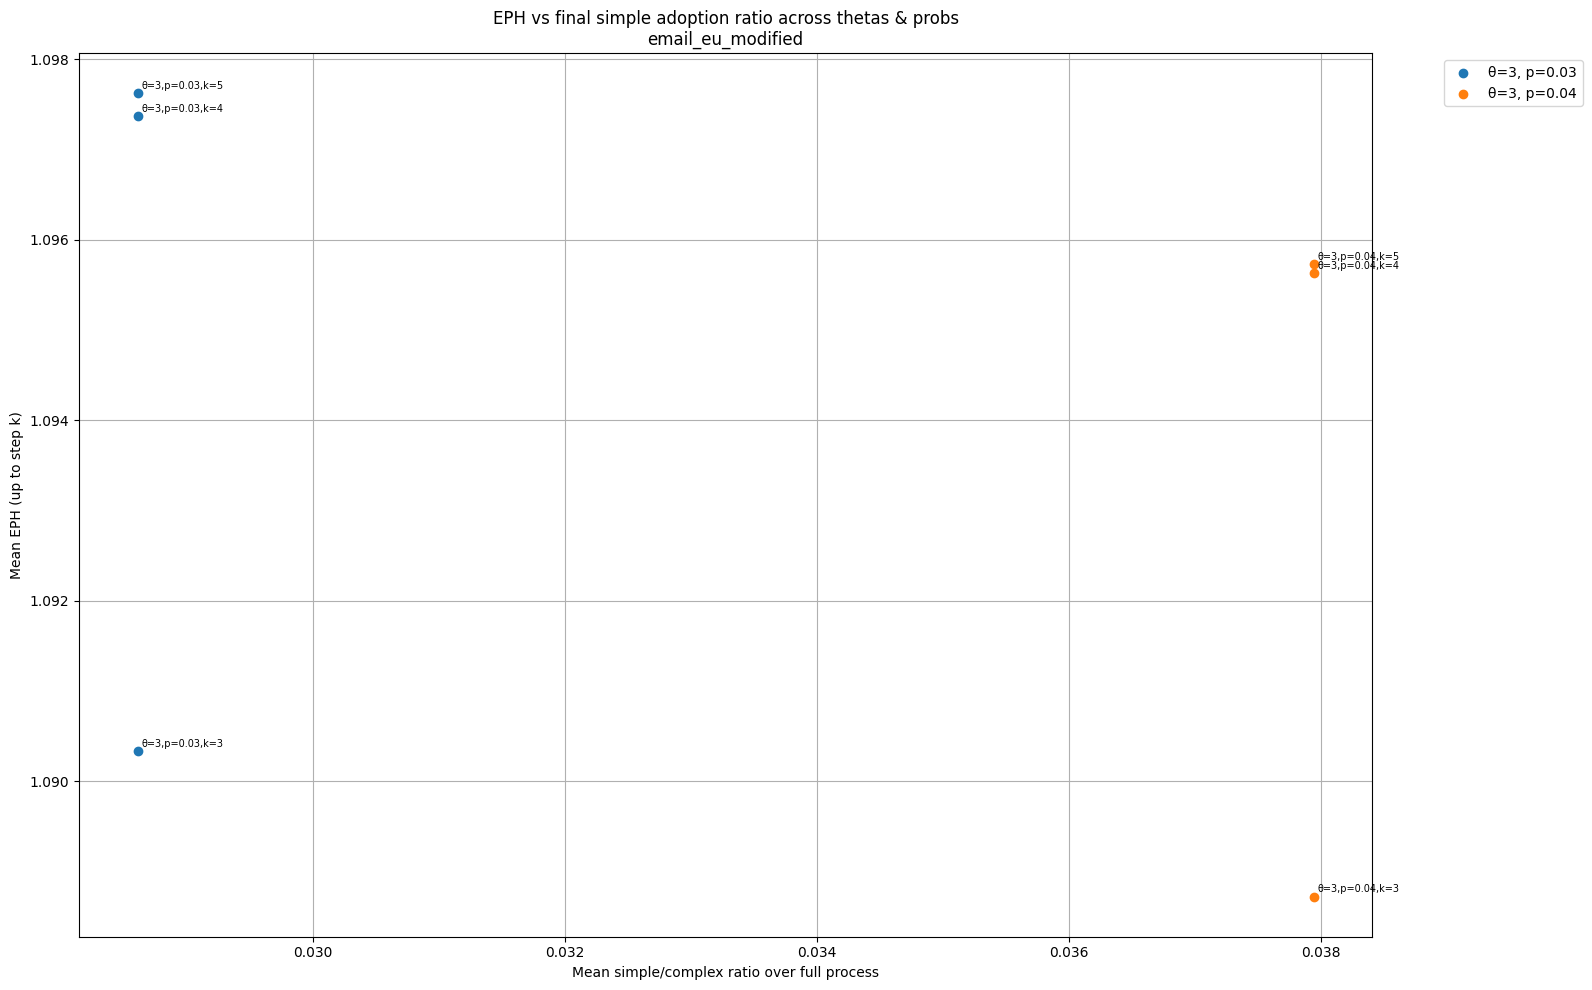

In [83]:
# Cell D (new): EPH(step-k) vs *final* simple/complex ratio, for multiple probs

network_name = "email_eu_modified"
thetas = [3]
prob_complexes = [0.03,0.04] # <-- now a set/list
k_values = [3,4,5]
fig, ax = plt.subplots(figsize=(16, 10))

for prob_complex in prob_complexes:
    for theta_curr in thetas:
        summary_curr = build_summary_over_k_with_final_ratio(
            network_name, theta_curr, prob_complex, k_values
        )

        # x = final ratio (same value for all k of this (theta, prob))
        x_vals = summary_curr["mean_final_simple_ratio"]
        y_vals = summary_curr["mean_EPH"]

        ax.scatter(
            x_vals,
            y_vals,
            label=f"θ={theta_curr}, p={prob_complex}"
        )

        # annotate each point with k (so you still see which EPH horizon it is)
        for _, row in summary_curr.iterrows():
            ax.annotate(
                f"θ={theta_curr},p={prob_complex},k={int(row['k'])}",
                (row["mean_final_simple_ratio"], row["mean_EPH"]),
                textcoords="offset points",
                xytext=(3, 3),
                fontsize=7
            )

ax.set_xlabel("Mean simple/complex ratio over full process")
ax.set_ylabel("Mean EPH (up to step k)")
ax.set_title(f"EPH vs final simple adoption ratio across thetas & probs\n{network_name}")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
